# Website Traffic Analysis

Importing important Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

Load Dataset

In [2]:
df = pd.read_csv("traffic.csv")

Understand Dataset

In [3]:
print(df.head())

print(df.shape)

print(df.info())

print(df.isnull().sum())

   event        date       country      city  \
0  click  21-08-2021  Saudi Arabia    Jeddah   
1  click  21-08-2021  Saudi Arabia    Jeddah   
2  click  21-08-2021         India  Ludhiana   
3  click  21-08-2021        France   Unknown   
4  click  21-08-2021      Maldives      Malé   

                              artist          album          track  \
0                             Tesher    Jalebi Baby    Jalebi Baby   
1                             Tesher    Jalebi Baby    Jalebi Baby   
2                      Reyanna Maria      So Pretty      So Pretty   
3  Simone & Simaria, Sebastian Yatra  No Llores Más  No Llores Más   
4                             Tesher    Jalebi Baby    Jalebi Baby   

           isrc                                linkid  
0  QZNWQ2070741  2d896d31-97b6-4869-967b-1c5fb9cd4bb8  
1  QZNWQ2070741  2d896d31-97b6-4869-967b-1c5fb9cd4bb8  
2  USUM72100871  23199824-9cf5-4b98-942a-34965c3b0cc2  
3  BRUM72003904  35573248-4e49-47c7-af80-08a960fa74cd  
4  QZNWQ20

Data Cleaning

In [4]:
#removing duplicate values
df.drop_duplicates(inplace=True)

#handling missing values
df.isnull().sum()

df.fillna("Unknown", inplace=True)

Saving Cleaned Dataset Code

In [5]:
# Saving the cleaned dataset
df.to_csv("website_traffic_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


Converting Date

In [6]:
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

Creating User Definition

In [7]:
df['user'] = (
    df['country'].astype(str)
    + "_"
    + df['city'].astype(str)
)

Sessions

In [8]:
total_sessions = df['linkid'].nunique()

print("Total Sessions:", total_sessions)

Total Sessions: 3839


Total Users

In [9]:
total_users = df['user'].nunique()

print("Total Users:", total_users)

Total Users: 12478


Event Analysis

event
pageview    73360
click       32499
preview     16708
Name: count, dtype: int64


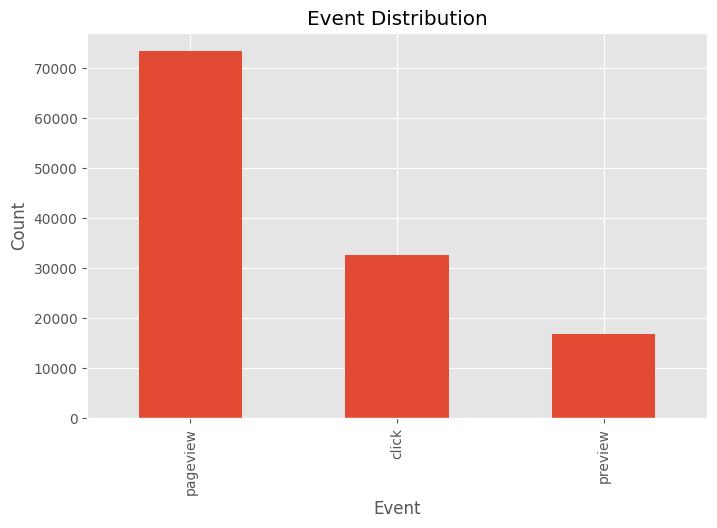

In [10]:
event_counts = df['event'].value_counts()

print(event_counts)

plt.figure(figsize=(8,5))

event_counts.plot(kind='bar')

plt.title("Event Distribution")
plt.xlabel("Event")
plt.ylabel("Count")

plt.show()

Top Countries

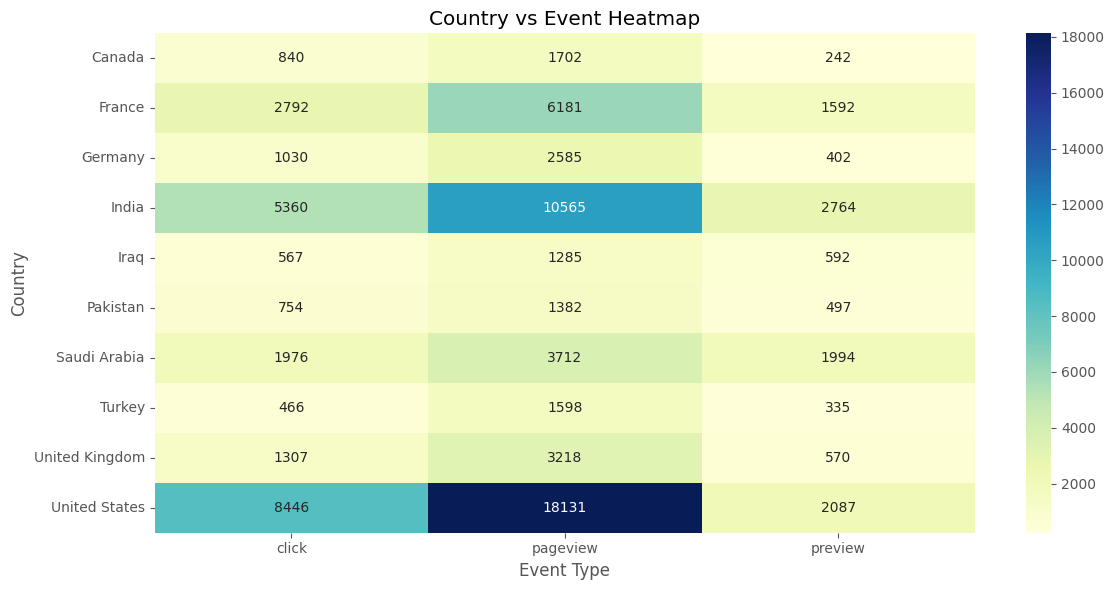

In [11]:
# Top 10 countries
top_countries = df['country'].value_counts().head(10).index

# Filter data
heatmap_data = df[df['country'].isin(top_countries)]

# Create pivot table
pivot = pd.crosstab(
    heatmap_data['country'],
    heatmap_data['event']
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title('Country vs Event Heatmap')
plt.xlabel('Event Type')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

Top Cities

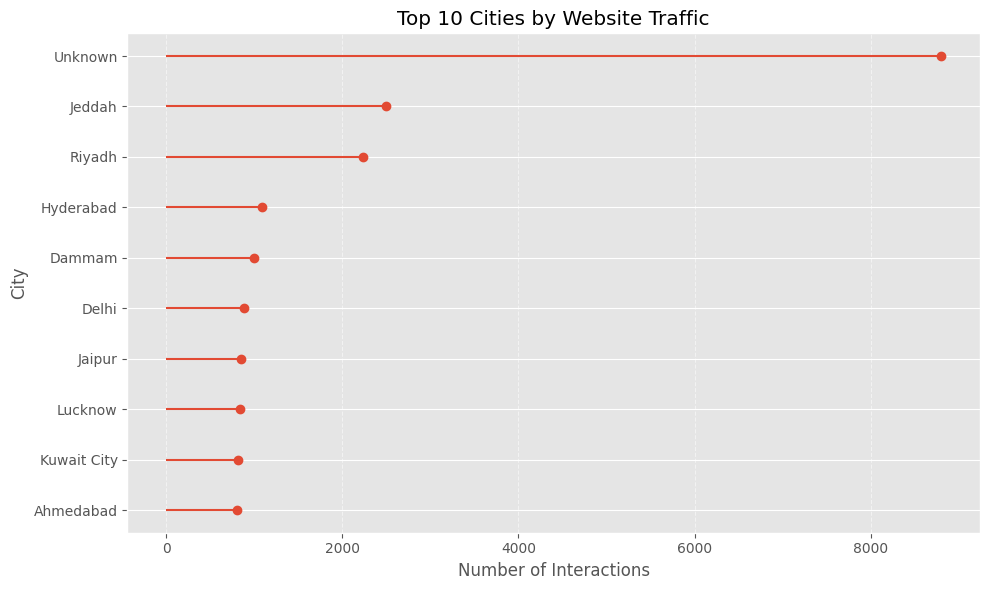

In [12]:
# Top 10 Cities
top_cities = df['city'].value_counts().head(10).sort_values()

plt.figure(figsize=(10,6))

# Draw lines
plt.hlines(
    y=top_cities.index,
    xmin=0,
    xmax=top_cities.values
)

# Draw points
plt.plot(
    top_cities.values,
    top_cities.index,
    "o"
)

plt.title("Top 10 Cities by Website Traffic")
plt.xlabel("Number of Interactions")
plt.ylabel("City")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Top Artists

artist
Tesher                                                          8288
Anne-Marie                                                      4029
Tundra Beats                                                    3951
Roddy Ricch                                                     3107
Olivia Rodrigo                                                  3037
Surf Mesa, Emilee                                               2956
DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna    2865
Reyanna Maria                                                   2675
PinkPantheress                                                  2446
50 Cent, Olivia                                                 2390
Name: count, dtype: int64


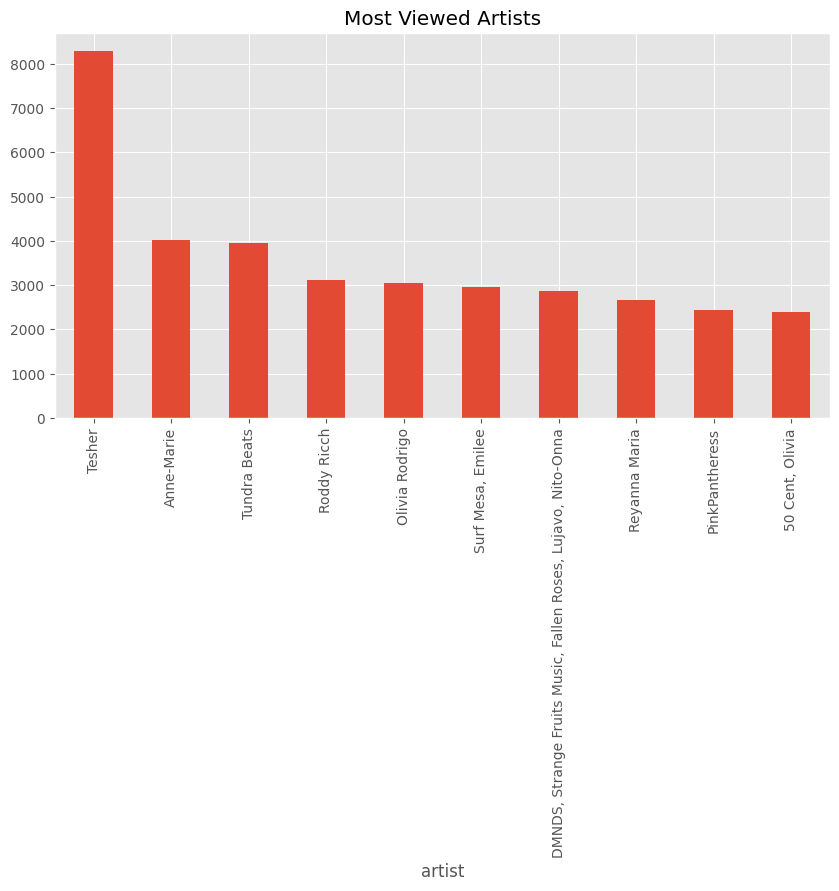

In [13]:
top_artists = (
    df['artist']
    .value_counts()
    .head(10)
)

print(top_artists)
plt.figure(figsize=(10,5))

top_artists.plot(kind='bar')

plt.title("Most Viewed Artists")

plt.show()

Top Tracks

track
Jalebi Baby                              8288
Beautiful                                4037
Beautiful Day                            3951
Late At Night                            3059
ily (i love you baby) (feat. Emilee)     2956
Calabria (feat. Lujavo & Nito-Onna)      2865
So Pretty                                2830
Candy Shop                               2397
Summer of Love (Shawn Mendes & Tainy)    2108
Build a Bitch                            2072
Name: count, dtype: int64


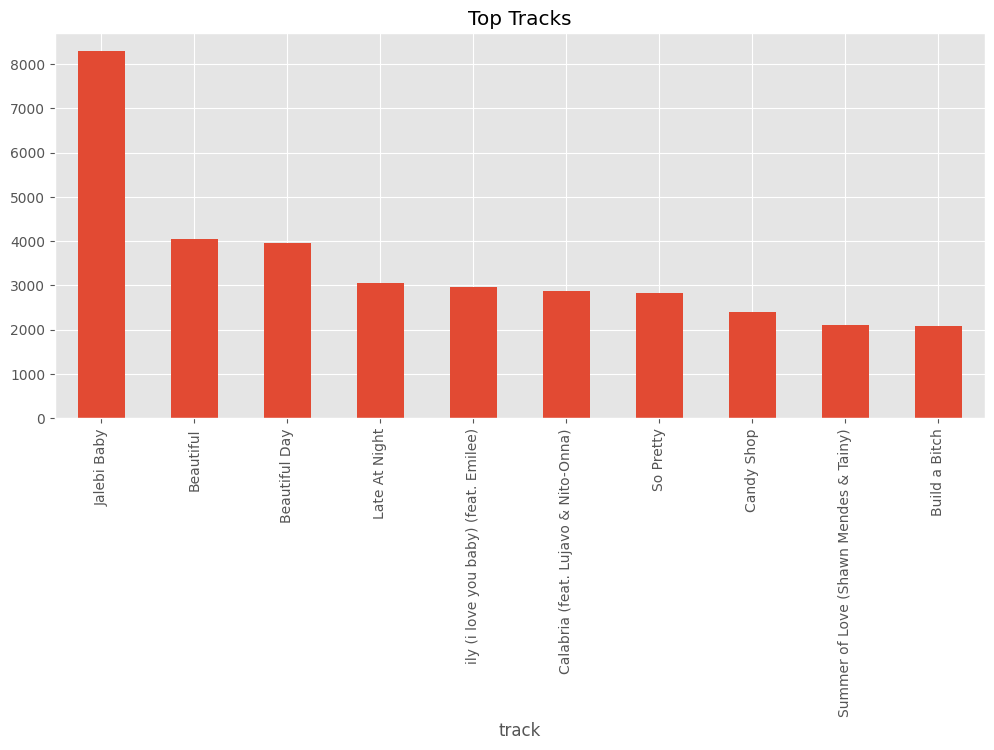

In [14]:
top_tracks = (
    df['track']
    .value_counts()
    .head(10)
)

print(top_tracks)
plt.figure(figsize=(12,5))

top_tracks.plot(kind='bar')

plt.title("Top Tracks")

plt.show()

Traffic Source Approximation

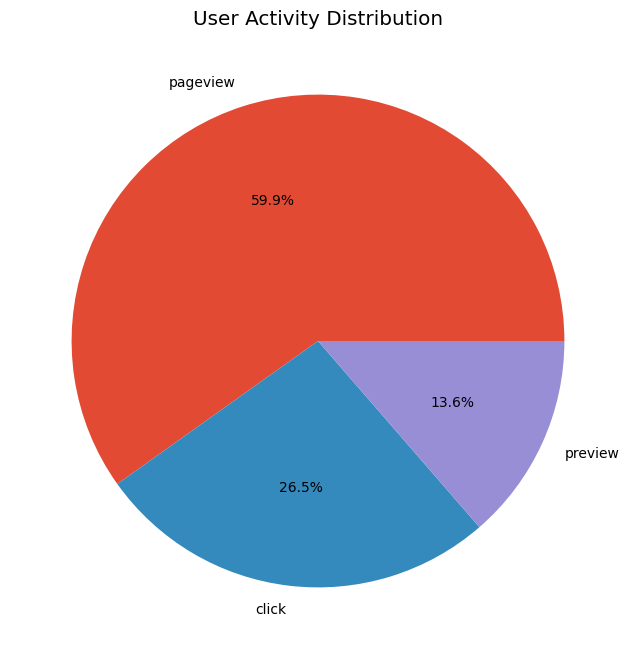

In [15]:
plt.figure(figsize=(8,8))

df['event'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")

plt.title("User Activity Distribution")

plt.show()

Daily Traffic Trend

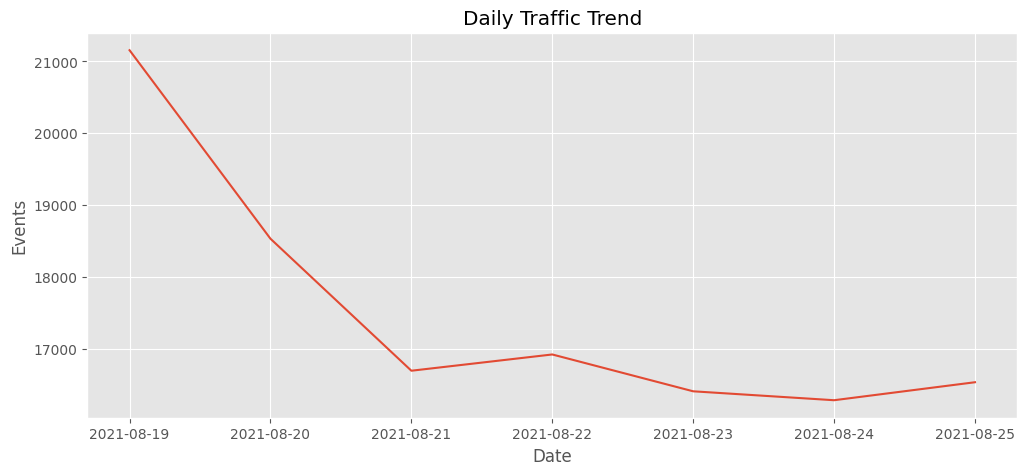

In [16]:
daily_traffic = (
    df.groupby(df['date'].dt.date)
      .size()
)

plt.figure(figsize=(12,5))

daily_traffic.plot()

plt.title("Daily Traffic Trend")

plt.xlabel("Date")
plt.ylabel("Events")

plt.show()

Bounce Rate Approximation

In [17]:
link_events = (
    df.groupby('linkid')
      .size()
)

bounce_links = (
    link_events[link_events == 1]
    .count()
)

bounce_rate = (
    bounce_links /
    total_sessions
) * 100

print("Bounce Rate:", round(bounce_rate,2), "%")

Bounce Rate: 35.56 %


Average Session Duration Approximation

In [18]:
avg_session_activity = (
    df.groupby('linkid')
      .size()
      .mean()
)

print(
    "Average Events Per Session:",
    round(avg_session_activity,2)
)

Average Events Per Session: 31.93


User Journey

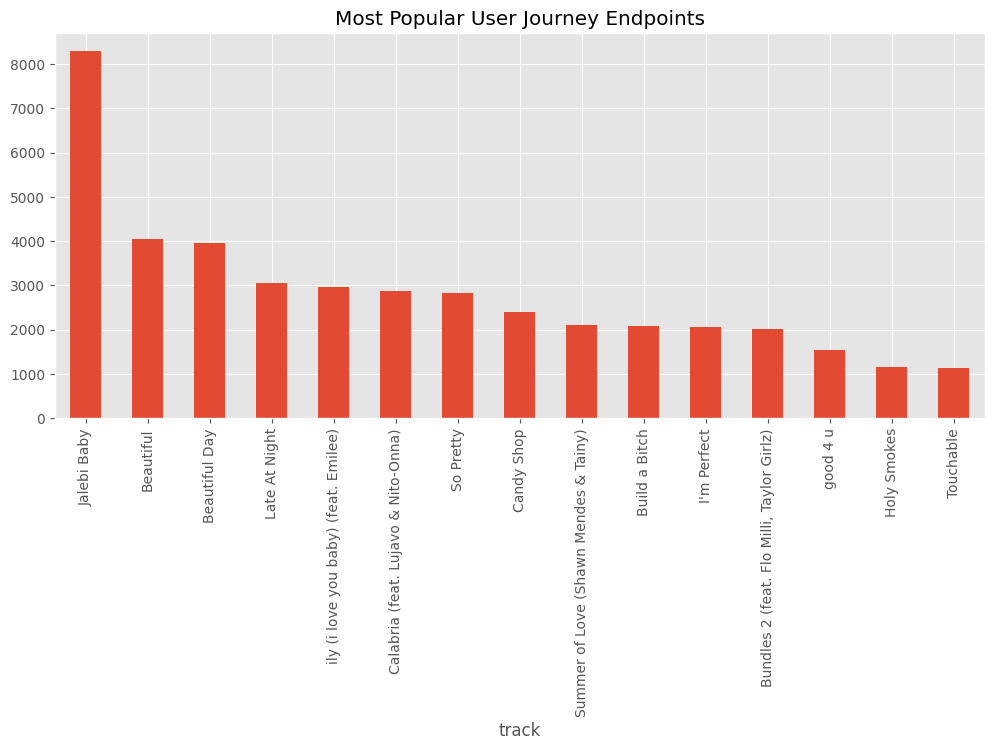

In [19]:
journey = (
    df.groupby('track')
      .size()
      .sort_values(ascending=False)
      .head(15)
)

journey.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Most Popular User Journey Endpoints")

plt.show()

KPI Dashboard Table

In [20]:
summary = pd.DataFrame({

    "Metric":[
        "Users",
        "Sessions",
        "Bounce Rate",
        "Avg Session Activity"
    ],

    "Value":[
        total_users,
        total_sessions,
        round(bounce_rate,2),
        round(avg_session_activity,2)
    ]
})

print(summary)

                 Metric     Value
0                 Users  12478.00
1              Sessions   3839.00
2           Bounce Rate     35.56
3  Avg Session Activity     31.93


5 Optimization Recommendations for Alfido Tech





1. Optimize High-Traffic Tracks

Focus marketing efforts on tracks receiving the highest user engagement.

2. Reduce Single-Interaction Sessions

Improve content and CTA placement to encourage additional interactions.

3. Personalize User Experience

Recommend similar artists and tracks based on user behavior.

4. Expand High-Performing Geographic Markets

Target countries and cities generating the highest traffic.

5. Improve Link Engagement

Add stronger call-to-action elements around track and album pages to increase conversions.